In [1]:
import sys
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

from helpers import PlotROCCurve

In [2]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.utils import resample
import numpy as np
import pandas as pd

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def false_negative_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else np.nan

def bootstrap_fairness_metric_ci(df, y_true_col, y_pred_col, y_score_col, group_col, B=1000, random_seed=42):
    group_vals = df[group_col].unique()

    metric_funcs = {
        'accuracy': accuracy_score,
        'precision': precision_score,
        'recall': recall_score,
        'f1': f1_score,
        'specificity': specificity_score,
        'fpr': false_positive_rate,
        'fnr': false_negative_rate,
        'selection_rate': selection_rate
    }

    results = {metric: {g: [] for g in group_vals} for metric in metric_funcs}
    results['auc'] = {g: [] for g in group_vals}

    for b in range(B):
        sample = resample(df, replace=True, random_state=random_seed + b)

        mf = MetricFrame(
            metrics=metric_funcs,
            y_true=sample[y_true_col],
            y_pred=sample[y_pred_col],
            sensitive_features=sample[group_col]
        )

        for metric in metric_funcs:
            for g in group_vals:
                results[metric][g].append(mf.by_group[metric][g])

        for g in group_vals:
            mask = sample[group_col] == g
            auc_val = roc_auc_score(sample.loc[mask, y_true_col], sample.loc[mask, y_score_col])
            results['auc'][g].append(auc_val)

    rows = []
    for metric in results:
        for g in group_vals:
            values = results[metric][g]
            rows.append({
                'Metric': metric,
                'Group': g,
                'Mean': np.mean(values),
                'CI_lower': np.percentile(values, 2.5),
                'CI_upper': np.percentile(values, 97.5)
            })

    return pd.DataFrame(rows)

In [3]:
df_train = pd.read_csv('/Users/xinniemai/Documents/Fairness Benchmark/fairness/stanford_train.csv')
df_test = pd.read_csv('/Users/xinniemai/Documents/Fairness Benchmark/fairness/stanford_test.csv')

In [4]:
confidence_interval = 95
random_seed=0
random.seed(random_seed)
np.random.seed(random_seed)

In [5]:
variable = ["age", "gender",

            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d",
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d",

            "triage_temperature", "triage_heartrate", "triage_resprate",
            "triage_o2sat", "triage_sbp", "triage_dbp", "triage_acuity",

            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache",
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough",
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",

            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia",
            "cci_Pulmonary", "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1",
            "cci_DM2", "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2",
            "cci_Cancer2", "cci_HIV",

            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy",
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss",
            "eci_Anemia", "eci_Alcohol", "eci_Drugs","eci_Psychoses", "eci_Depression"]

outcome = "outcome_hospitalization" # or "outcome_critical"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()

In [7]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])

result_list = []

# Logistic Regression

Logistic Regression (with standardization):
Training time: 0.584434986114502 seconds
AUC: 0.7905344246905095
AUPRC: 0.5322877745486854
Sensitivity: 0.734337555631633
Specificity: 0.710567646398923
Score thresold: 0.23312949569908817
2.5 97.5


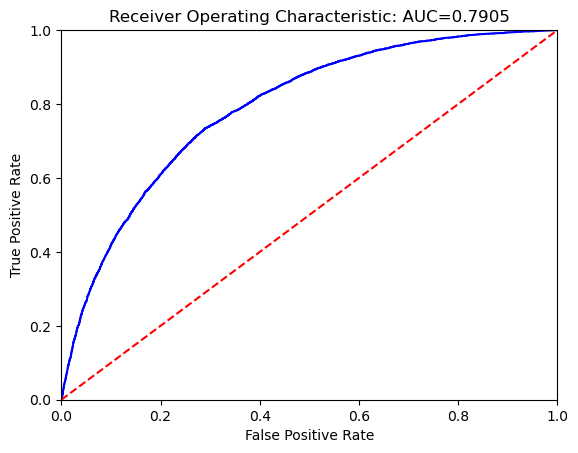

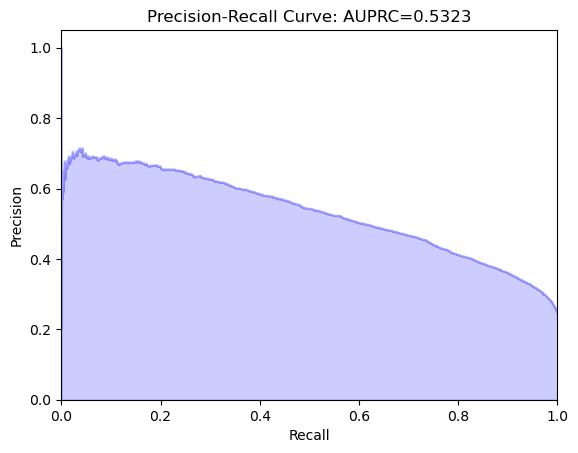

Accuracy: 0.783270


In [8]:
print("Logistic Regression (with standardization):")

vars_to_standardize = [
    "age", "n_ed_30d", "n_ed_90d", "n_ed_365d",
    "n_hosp_30d", "n_hosp_90d", "n_hosp_365d",
    "n_icu_30d", "n_icu_90d", "n_icu_365d",
    "triage_temperature", "triage_heartrate",
    "triage_resprate", "triage_o2sat",
    "triage_sbp", "triage_dbp"
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[vars_to_standardize] = scaler.fit_transform(X_train[vars_to_standardize])
X_test_scaled[vars_to_standardize] = scaler.transform(X_test[vars_to_standardize])

logreg = LogisticRegression(random_state=random_seed, max_iter=1000)
start = time.time()
logreg.fit(X_train_scaled, y_train)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

probs = logreg.predict_proba(X_test_scaled)
y_pred_lr = logreg.predict(X_test_scaled)

result = PlotROCCurve(probs[:,1], y_test, ci=confidence_interval, random_seed=random_seed)
results = ["LR"]
results.extend(result)
results.append(runtime)

acc = accuracy_score(y_test, y_pred_lr)
results.append(acc)
result_list.append(results)

print(f"Accuracy: {acc:.6f}")

In [9]:
probs = logreg.predict_proba(X_test_scaled)
y_pred = (probs[:, 1] >= 0.233).astype(int)

In [10]:
def _clean_series(s):
    s = s.fillna('').astype(str).str.strip()
    invalid = {'', 'nan', 'unknown', 'unable to obtain', 'declines to state'}
    return s, ~s.str.lower().isin(invalid)

def prepare_group_fair_df(attr_name, mapping=None):
    raw = df_test[attr_name]
    s_clean, valid_mask = _clean_series(raw)
    idx = valid_mask[valid_mask].index if isinstance(valid_mask, pd.Series) else valid_mask
    group_vals = s_clean[valid_mask]
    if mapping:
        group_mapped = group_vals.str.upper().map(mapping)
    else:
        group_mapped = group_vals
    fair_df = pd.DataFrame({
        'y_true': y_test[valid_mask],
        'y_pred': y_pred[valid_mask],
        'y_score': probs[:, 1][valid_mask],
        attr_name: group_mapped
    })
    return fair_df, group_mapped, valid_mask

def print_bootstrap_group_metrics(ci_df, group_label_to_id, heading=None):
    if heading:
        print(f"\n{heading}")
    for label, gid in group_label_to_id.items():
        group_metrics = ci_df[ci_df['Group'] == gid]
        print(f"\n{label}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")

In [11]:
gender_map = {'F': 0, 'M': 1}
fair_df, gender_grouped, valid_mask_gender = prepare_group_fair_df('gender', mapping=gender_map)

ci_df_gender = bootstrap_fairness_metric_ci(
    df=fair_df,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='gender',
    B=1000,
    random_seed=42
)

print_bootstrap_group_metrics(
    ci_df_gender,
    group_label_to_id={'Female': 0, 'Male': 1},
    heading="=== Logistic Regression Per-Gender Metrics (Mean + 95% CI) ==="
)


=== Logistic Regression Per-Gender Metrics (Mean + 95% CI) ===

Female:
accuracy         Mean = 0.74975, CI = (0.74262, 0.75744)
precision        Mean = 0.45627, CI = (0.44182, 0.47228)
recall           Mean = 0.69662, CI = (0.67928, 0.71353)
f1               Mean = 0.55136, CI = (0.53769, 0.56496)
specificity      Mean = 0.76481, CI = (0.75684, 0.77283)
fpr              Mean = 0.23519, CI = (0.22717, 0.24316)
fnr              Mean = 0.30338, CI = (0.28647, 0.32072)
selection_rate   Mean = 0.33707, CI = (0.32909, 0.34582)
auc              Mean = 0.79635, CI = (0.78697, 0.80565)

Male:
accuracy         Mean = 0.67737, CI = (0.66917, 0.68611)
precision        Mean = 0.45218, CI = (0.43837, 0.46642)
recall           Mean = 0.76978, CI = (0.75410, 0.78403)
f1               Mean = 0.56968, CI = (0.55601, 0.58295)
specificity      Mean = 0.64187, CI = (0.63230, 0.65191)
fpr              Mean = 0.35813, CI = (0.34809, 0.36770)
fnr              Mean = 0.23022, CI = (0.21597, 0.24590)
selectio

In [12]:
def add_error_columns(ci_df, mean_col='Mean', lower_col='CI_lower', upper_col='CI_upper'):
    ci_df = ci_df.copy()
    ci_df['Error Lower'] = ci_df[mean_col] - ci_df[lower_col]
    ci_df['Error Upper'] = ci_df[upper_col] - ci_df[mean_col]
    return ci_df

def plot_group_ci(ci_df, group_col='Group', mean_col='Mean',
                  err_low='Error Lower', err_up='Error Upper',
                  cmap='lightcoral', figsize_per_metric=(4, 4), title=None):
    metrics = ci_df['Metric'].unique()
    n = len(metrics)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_metric[0] * n, figsize_per_metric[1]), squeeze=False)
    axes = axes.ravel()
    for i, metric in enumerate(metrics):
        ax = axes[i]
        subset = ci_df[ci_df['Metric'] == metric].sort_values(by=group_col)
        groups = subset[group_col].astype(str)
        means = subset[mean_col].to_numpy(dtype=float)
        lower = subset[err_low].to_numpy(dtype=float)
        upper = subset[err_up].to_numpy(dtype=float)
        yerr = np.vstack([lower, upper])
        x = np.arange(len(groups))
        ax.bar(x, means, yerr=yerr, capsize=6, color=cmap)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=30, ha='right')
        ax.set_title(metric, fontsize=11)
        ax.set_xlabel(group_col)
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_subgroup_roc(fair_df, group_col, label_map=None, colors=None, figsize=(8,6), title=None):
    """
    Plots ROC curves per subgroup. label_map maps group values -> display labels.
    Skips groups with <2 classes in y_true.
    """
    groups = sorted(fair_df[group_col].unique(), key=lambda x: (str(x)))
    plt.figure(figsize=figsize)
    any_plotted = False
    for i, g in enumerate(groups):
        group_df = fair_df[fair_df[group_col] == g]
        if group_df.empty or group_df['y_true'].nunique() < 2:
            continue
        try:
            fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
            auc = roc_auc_score(group_df['y_true'], group_df['y_score'])
        except ValueError:
            continue
        label = label_map.get(g, str(g)) if label_map else str(g)
        color = None
        if colors:
            color = colors.get(g) if isinstance(colors, dict) else colors[i % len(colors)]
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)
        any_plotted = True
    plt.plot([0,1],[0,1],'k--', linewidth=0.8)
    if title:
        plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    if any_plotted:
        plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

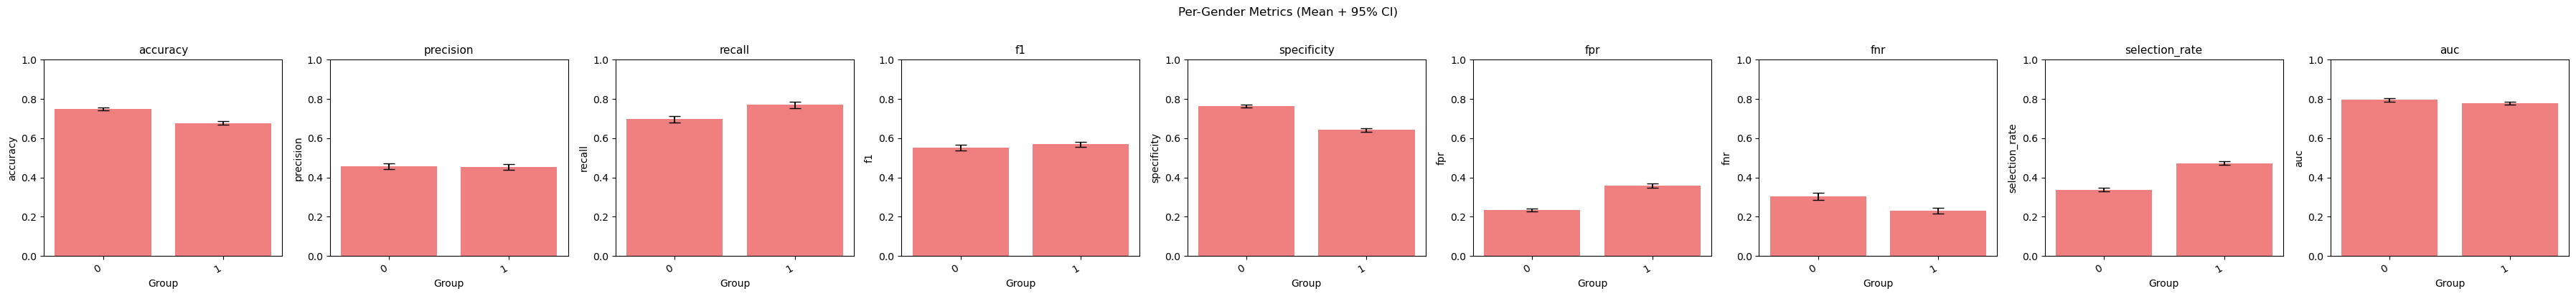

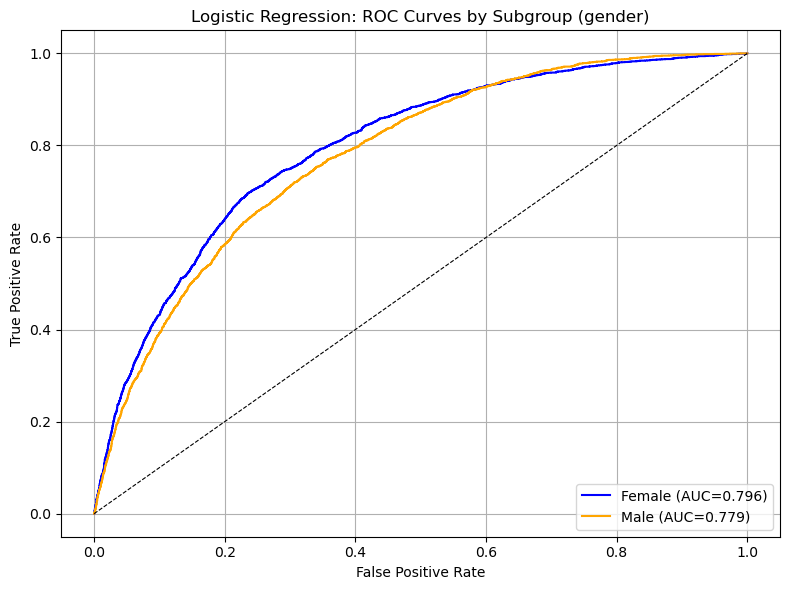

In [13]:
ci_df_gender = add_error_columns(ci_df_gender)

plot_group_ci(
    ci_df_gender,
    group_col='Group',
    mean_col='Mean',
    err_low='Error Lower',
    err_up='Error Upper',
    cmap='lightcoral',
    title='Per-Gender Metrics (Mean + 95% CI)'
)

label_map = {0: 'Female', 1: 'Male'}
plot_subgroup_roc(
    fair_df,
    group_col='gender',
    label_map=label_map,
    colors={0: 'blue', 1: 'orange'},
    title='Logistic Regression: ROC Curves by Subgroup (gender)'
)

Race and Ethnicity Mapping

In [14]:
race_raw = df_test['race'].astype(str)
ethnicity_raw = df_test['ethnicity'].astype(str)

valid_mask_race_ethnicity = (
    race_raw.notna() &
    ethnicity_raw.notna() &
    (race_raw.str.strip() != '') &
    (ethnicity_raw.str.strip() != '') &
    (race_raw != 'nan') &
    (ethnicity_raw != 'nan') &
    (~race_raw.str.lower().isin(['unknown', 'unable to obtain', 'declines to state'])) &
    (~ethnicity_raw.str.lower().isin(['unknown', 'unable to obtain', 'declines to state']))
)

y_test_race_ethnicity = y_test[valid_mask_race_ethnicity]
y_pred_race_ethnicity = y_pred[valid_mask_race_ethnicity]
y_score_race_ethnicity = probs[:, 1][valid_mask_race_ethnicity]

race_clean = race_raw[valid_mask_race_ethnicity].str.strip()
ethnicity_clean = ethnicity_raw[valid_mask_race_ethnicity].str.strip()

print("Unique race values:")
print(sorted(race_clean.unique()))
print("\nUnique ethnicity values:")
print(sorted(ethnicity_clean.unique()))

def map_race_ethnicity(race_val, ethnicity_val):
    race_str = str(race_val).strip()
    ethnicity_str = str(ethnicity_val).strip()
    
    # Hispanic/Latino takes priority regardless of race
    if 'Hispanic/Latino' in ethnicity_str:
        return 'Hispanic/Latino'
    # Then map by race
    elif 'White' in race_str:
        return 'White'
    elif 'Asian' in race_str:
        return 'Asian'
    elif 'Black or African American' in race_str:
        return 'Black or African American'
    else:
        return 'Other'

Unique race values:
['American Indian or Alaska Native', 'Asian', 'Black or African American', 'Native Hawaiian or Other Pacific Islander', 'Other', 'White']

Unique ethnicity values:
['Hispanic/Latino', 'Non-Hispanic/Non-Latino']


In [15]:
race_ethnicity_grouped = [map_race_ethnicity(r, e) for r, e in zip(race_clean, ethnicity_clean)]

fair_df_race_ethnicity = pd.DataFrame({
    'y_true': y_test_race_ethnicity,
    'y_pred': y_pred_race_ethnicity,
    'y_score': y_score_race_ethnicity,
    'race_ethnicity': race_ethnicity_grouped
})

print("\nRace/Ethnicity group distribution:")
print(fair_df_race_ethnicity['race_ethnicity'].value_counts())

ci_df_race_ethnicity = bootstrap_fairness_metric_ci(
    df=fair_df_race_ethnicity,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='race_ethnicity',
    B=1000,
    random_seed=42
)

print("\n=== Logistic Regression Per-Race/Ethnicity Metrics (Mean + 95% CI) ===")
for group in ['Asian', 'Black or African American', 'Hispanic/Latino', 'Other', 'White']:
    if group in ci_df_race_ethnicity['Group'].values:
        group_metrics = ci_df_race_ethnicity[ci_df_race_ethnicity['Group'] == group]
        print(f"\n{group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


Race/Ethnicity group distribution:
race_ethnicity
White                        8783
Hispanic/Latino              6450
Asian                        3856
Other                        2808
Black or African American    1462
Name: count, dtype: int64

=== Logistic Regression Per-Race/Ethnicity Metrics (Mean + 95% CI) ===

Asian:
accuracy         Mean = 0.70898, CI = (0.69367, 0.72270)
precision        Mean = 0.48852, CI = (0.46549, 0.50969)
recall           Mean = 0.78225, CI = (0.75660, 0.80694)
f1               Mean = 0.60136, CI = (0.58001, 0.62189)
specificity      Mean = 0.68039, CI = (0.66350, 0.69821)
fpr              Mean = 0.31961, CI = (0.30179, 0.33650)
fnr              Mean = 0.21775, CI = (0.19306, 0.24340)
selection_rate   Mean = 0.44947, CI = (0.43419, 0.46462)
auc              Mean = 0.79839, CI = (0.78308, 0.81263)

Black or African American:
accuracy         Mean = 0.73775, CI = (0.71418, 0.76001)
precision        Mean = 0.46218, CI = (0.41468, 0.50563)
recall           M

/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/3201342179.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

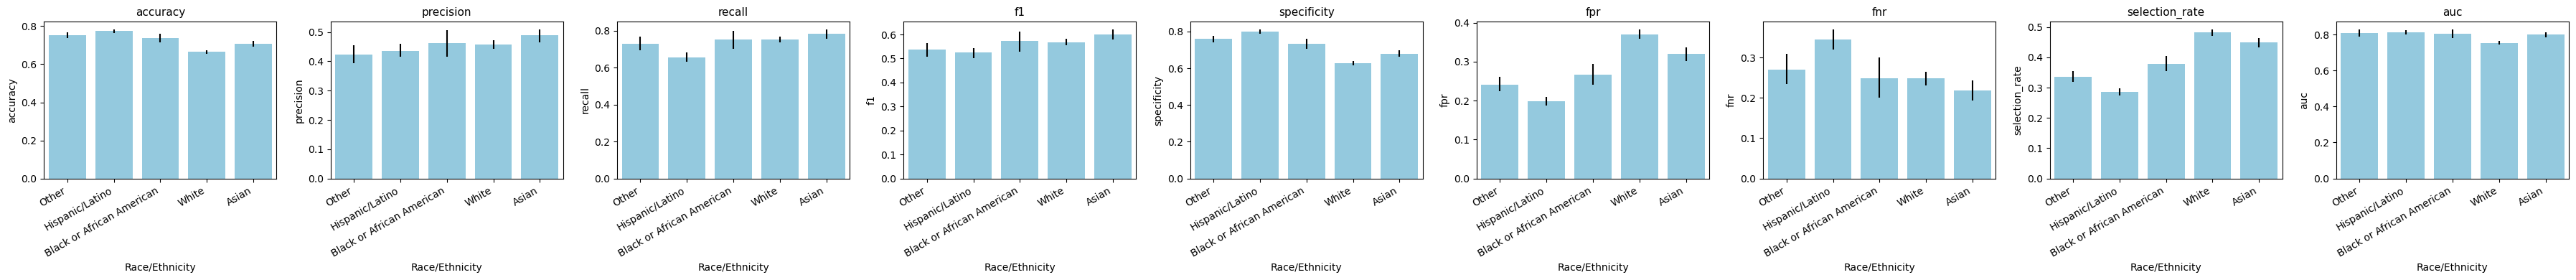

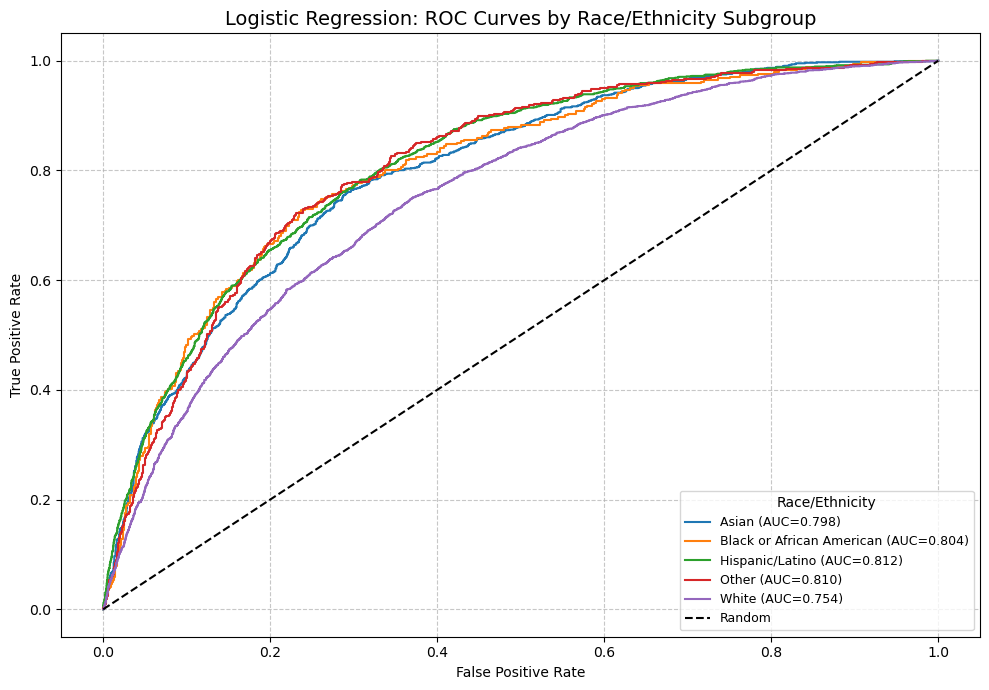

In [16]:
ci_df_race_ethnicity['Error Lower'] = ci_df_race_ethnicity['Mean'] - ci_df_race_ethnicity['CI_lower']
ci_df_race_ethnicity['Error Upper'] = ci_df_race_ethnicity['CI_upper'] - ci_df_race_ethnicity['Mean']

metrics = ci_df_race_ethnicity['Metric'].unique()
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    subset = ci_df_race_ethnicity[ci_df_race_ethnicity['Metric'] == metric]

    sns.barplot(
        data=subset,
        x='Group',
        y='Mean',
        yerr=[subset['Error Lower'], subset['Error Upper']],
        capsize=0.2,
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'{metric}', fontsize=11)
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

race_ethnicity_groups = fair_df_race_ethnicity['race_ethnicity'].unique()

plt.figure(figsize=(10, 7))

for group in sorted(race_ethnicity_groups):
    group_df = fair_df_race_ethnicity[fair_df_race_ethnicity['race_ethnicity'] == group]

    fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
    auc = roc_auc_score(group_df['y_true'], group_df['y_score'])

    plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Logistic Regression: ROC Curves by Race/Ethnicity Subgroup', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(title='Race/Ethnicity', loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Age Group

In [17]:
def plot_grouped_metrics_ci(ci_df, group_col='Group', mean_col='Mean', err_low='Error Lower', err_up='Error Upper', cmap='cornflowerblue'):
    metrics = ci_df['Metric'].unique()
    n_metrics = len(metrics)
    if n_metrics == 0:
        return
    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), squeeze=False)
    axes = axes.ravel()
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        subset = ci_df[ci_df['Metric'] == metric].sort_values(by=group_col)
        groups = subset[group_col].astype(str).tolist()
        means = subset[mean_col].to_numpy(dtype=float)
        err_lower = subset[err_low].to_numpy(dtype=float)
        err_upper = subset[err_up].to_numpy(dtype=float)
        # convert to symmetric matplotlib yerr format
        yerr = np.vstack([err_lower, err_upper])
        x = np.arange(len(groups))
        ax.bar(x, means, yerr=yerr, capsize=6, color=cmap)
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=30, ha='right')
        ax.set_title(metric, fontsize=11)
        ax.set_xlabel(group_col)
        ax.set_ylabel('Value')
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

def plot_group_roc_curves(fair_df, group_col, order=None, figsize=(10,7), title='ROC Curves by Group'):
    groups = fair_df[group_col].unique()
    if order is not None:
        # keep only groups present in data and in the supplied order
        groups = [g for g in order if g in fair_df[group_col].unique()]
    plt.figure(figsize=figsize)
    any_plotted = False
    for group in groups:
        group_df = fair_df[fair_df[group_col] == group]
        if group_df.empty:
            continue
        if group_df['y_true'].nunique() < 2:
            print(f"Skipping {group}: only one class present.")
            continue
        fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
        auc = roc_auc_score(group_df['y_true'], group_df['y_score'])
        plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')
        any_plotted = True
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title(title, fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(title=group_col, loc='lower right', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.7)
    if any_plotted:
        plt.tight_layout()
    plt.show()

In [18]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 150]
age_labels = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']

age_grouped = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=True)
valid_mask = age_grouped.notna()

y_test_age = y_test[valid_mask]
y_pred_age = y_pred[valid_mask]
y_score_age = probs[:, 1][valid_mask]
age_grouped_clean = age_grouped[valid_mask]

fair_df_age = pd.DataFrame({
    'y_true': y_test_age,
    'y_pred': y_pred_age,
    'y_score': y_score_age,
    'age_group': age_grouped_clean
})

ci_df_age = bootstrap_fairness_metric_ci(
    df=fair_df_age,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='age_group',
    B=1000,
    random_seed=42
)

print("\n=== Logistic Regression Per-Age Group Metrics(Mean + 95% CI) ===")
for group in age_labels:
    if group in ci_df_age['Group'].values:
        group_metrics = ci_df_age[ci_df_age['Group'] == group]
        print(f"\nAge Group {group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")



=== Logistic Regression Per-Age Group Metrics(Mean + 95% CI) ===

Age Group 18–24:
accuracy         Mean = 0.87685, CI = (0.86234, 0.89103)
precision        Mean = 0.42129, CI = (0.34459, 0.50304)
recall           Mean = 0.29186, CI = (0.23502, 0.35295)
f1               Mean = 0.34419, CI = (0.28328, 0.40872)
specificity      Mean = 0.94990, CI = (0.93835, 0.96014)
fpr              Mean = 0.05010, CI = (0.03986, 0.06165)
fnr              Mean = 0.70814, CI = (0.64705, 0.76498)
selection_rate   Mean = 0.07694, CI = (0.06497, 0.08986)
auc              Mean = 0.80573, CI = (0.77951, 0.83316)

Age Group 25–34:
accuracy         Mean = 0.85593, CI = (0.84439, 0.86746)
precision        Mean = 0.40911, CI = (0.36467, 0.45244)
recall           Mean = 0.44335, CI = (0.39455, 0.49200)
f1               Mean = 0.42532, CI = (0.38435, 0.46748)
specificity      Mean = 0.91238, CI = (0.90289, 0.92103)
fpr              Mean = 0.08762, CI = (0.07897, 0.09711)
fnr              Mean = 0.55665, CI = (0.50

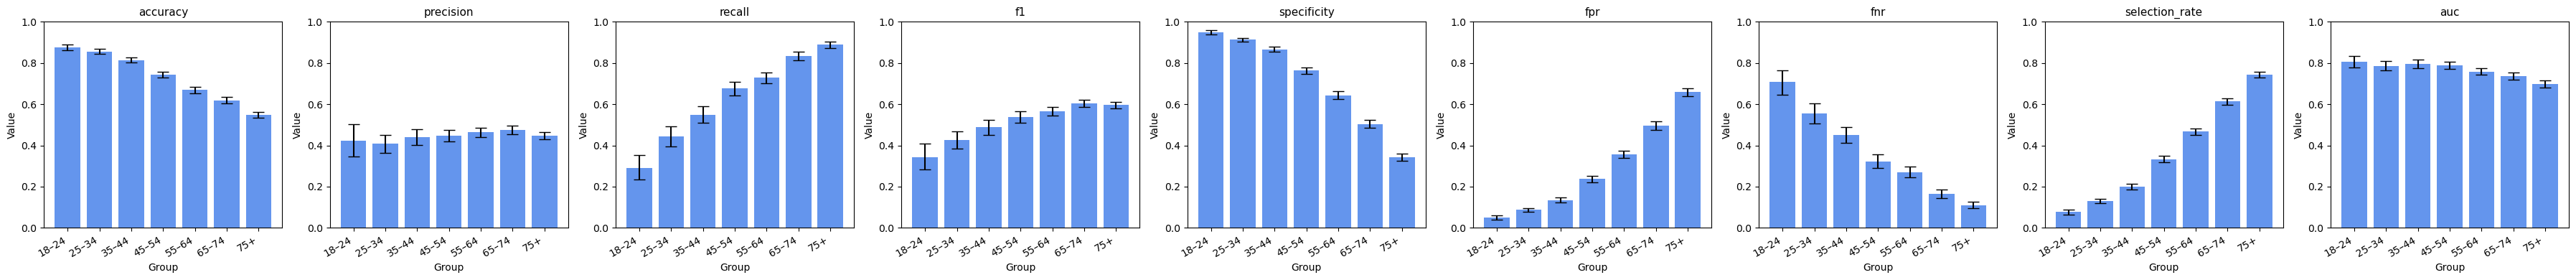

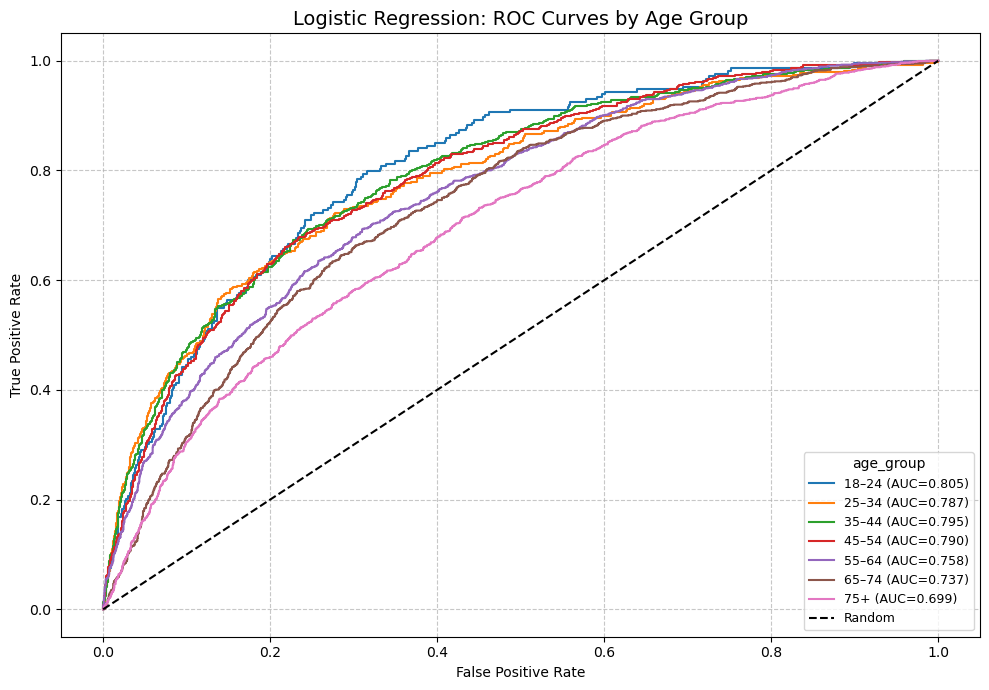

In [19]:
ci_df_age['Error Lower'] = ci_df_age['Mean'] - ci_df_age['CI_lower']
ci_df_age['Error Upper'] = ci_df_age['CI_upper'] - ci_df_age['Mean']

age_labels_ordered = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
ci_df_age['Group'] = pd.Categorical(ci_df_age['Group'], categories=age_labels_ordered, ordered=True)

plot_grouped_metrics_ci(ci_df_age, group_col='Group', cmap='cornflowerblue')
plot_group_roc_curves(fair_df_age, group_col='age_group', order=age_labels_ordered, title='Logistic Regression: ROC Curves by Age Group')

# Random Forest

RandomForest:
Training time: 10.526595830917358 seconds
AUC: 0.7972554337744587
AUPRC: 0.5435063607593934
Sensitivity: 0.7334816843546731
Specificity: 0.7169620821180166
Score thresold: 0.29
2.5 97.5


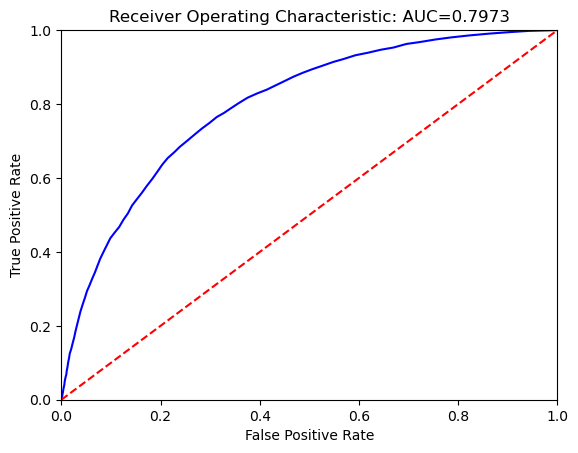

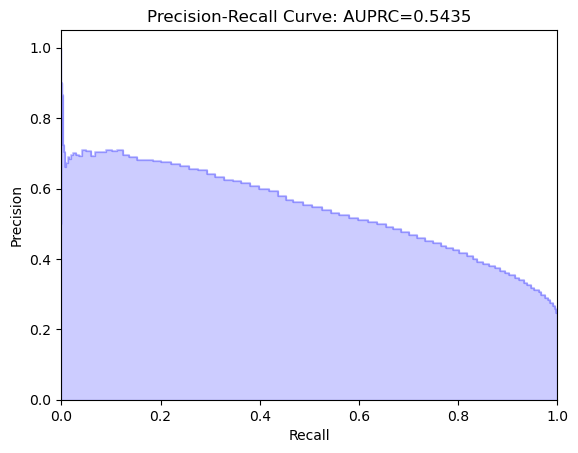

[0.10092514 0.01541553 0.01081222 0.01512884 0.02438131 0.00534447
 0.01188448 0.02823005 0.00061283 0.00125645 0.00225778 0.0683953
 0.09781401 0.05234953 0.0514879  0.09234307 0.08783206 0.04472084
 0.00810137 0.01008035 0.00385514 0.01161932 0.00388586 0.00292179
 0.00675703 0.00601806 0.0029821  0.00386256 0.00701559 0.01138562
 0.00680637 0.00759788 0.00281265 0.00859606 0.00422933 0.00193614
 0.0066172  0.00872414 0.0038754  0.00184056 0.0107198  0.0211849
 0.00391064 0.00784448 0.00076296 0.01052424 0.00536678 0.00624576
 0.01213657 0.00178687 0.00716645 0.00699584 0.00264746 0.00525522
 0.00688475 0.00536669 0.01224575 0.00289399 0.0052222  0.00520849
 0.00441467 0.00346297 0.00904016]


In [20]:
print("RandomForest:")
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

y_pred_rf = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred_rf)
results.append(acc)

In [21]:
probs = rf.predict_proba(X_test)
y_pred = (probs[:, 1] >= 0.29).astype(int)

In [22]:
gender_map = {'F': 0, 'M': 1}
fair_df, gender_grouped, valid_mask_gender = prepare_group_fair_df('gender', mapping=gender_map)

ci_df_gender = bootstrap_fairness_metric_ci(
    df=fair_df,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='gender',
    B=1000,
    random_seed=42
)

print_bootstrap_group_metrics(
    ci_df_gender,
    group_label_to_id={'Female': 0, 'Male': 1},
    heading="=== Random Forest Per-Gender Metrics (Mean + 95% CI) ==="
)


=== Random Forest Per-Gender Metrics (Mean + 95% CI) ===

Female:
accuracy         Mean = 0.74255, CI = (0.73504, 0.75017)
precision        Mean = 0.44767, CI = (0.43325, 0.46285)
recall           Mean = 0.71068, CI = (0.69341, 0.72769)
f1               Mean = 0.54928, CI = (0.53527, 0.56266)
specificity      Mean = 0.75158, CI = (0.74314, 0.76012)
fpr              Mean = 0.24842, CI = (0.23988, 0.25686)
fnr              Mean = 0.28932, CI = (0.27231, 0.30659)
selection_rate   Mean = 0.35047, CI = (0.34187, 0.35865)
auc              Mean = 0.80248, CI = (0.79377, 0.81105)

Male:
accuracy         Mean = 0.69584, CI = (0.68723, 0.70400)
precision        Mean = 0.47005, CI = (0.45619, 0.48401)
recall           Mean = 0.75514, CI = (0.73976, 0.77034)
f1               Mean = 0.57939, CI = (0.56626, 0.59260)
specificity      Mean = 0.67307, CI = (0.66231, 0.68276)
fpr              Mean = 0.32693, CI = (0.31724, 0.33769)
fnr              Mean = 0.24486, CI = (0.22966, 0.26024)
selection_rate

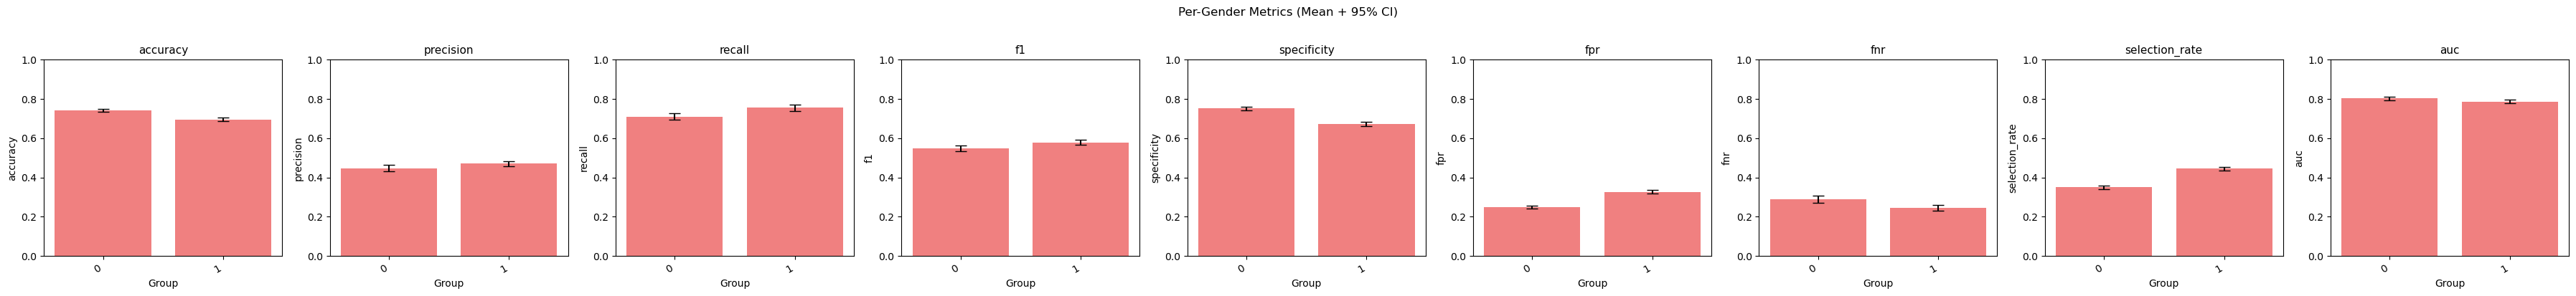

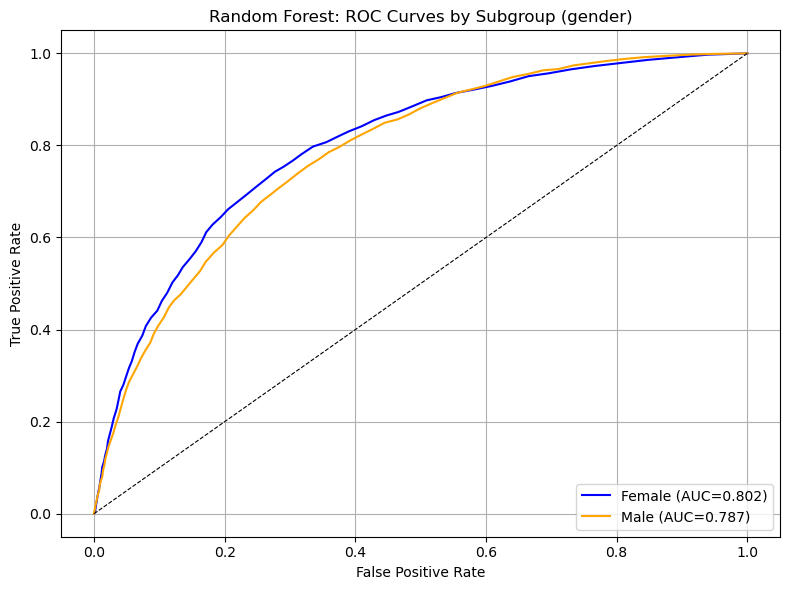

In [23]:
ci_df_gender = add_error_columns(ci_df_gender)

plot_group_ci(
    ci_df_gender,
    group_col='Group',
    mean_col='Mean',
    err_low='Error Lower',
    err_up='Error Upper',
    cmap='lightcoral',
    title='Per-Gender Metrics (Mean + 95% CI)'
)

label_map = {0: 'Female', 1: 'Male'}
plot_subgroup_roc(
    fair_df,
    group_col='gender',
    label_map=label_map,
    colors={0: 'blue', 1: 'orange'},
    title='Random Forest: ROC Curves by Subgroup (gender)'
)

In [24]:
race_ethnicity_grouped = [map_race_ethnicity(r, e) for r, e in zip(race_clean, ethnicity_clean)]

fair_df_race_ethnicity = pd.DataFrame({
    'y_true': y_test_race_ethnicity,
    'y_pred': y_pred_race_ethnicity,
    'y_score': y_score_race_ethnicity,
    'race_ethnicity': race_ethnicity_grouped
})

ci_df_race_ethnicity = bootstrap_fairness_metric_ci(
    df=fair_df_race_ethnicity,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='race_ethnicity',
    B=1000,
    random_seed=42
)

print("\n=== Random Forest Per-Race/Ethnicity Metrics (Mean + 95% CI) ===")
for group in ['Asian', 'Black or African American', 'Hispanic/Latino', 'Other', 'White']:
    if group in ci_df_race_ethnicity['Group'].values:
        group_metrics = ci_df_race_ethnicity[ci_df_race_ethnicity['Group'] == group]
        print(f"\n{group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


=== Random Forest Per-Race/Ethnicity Metrics (Mean + 95% CI) ===

Asian:
accuracy         Mean = 0.70898, CI = (0.69367, 0.72270)
precision        Mean = 0.48852, CI = (0.46549, 0.50969)
recall           Mean = 0.78225, CI = (0.75660, 0.80694)
f1               Mean = 0.60136, CI = (0.58001, 0.62189)
specificity      Mean = 0.68039, CI = (0.66350, 0.69821)
fpr              Mean = 0.31961, CI = (0.30179, 0.33650)
fnr              Mean = 0.21775, CI = (0.19306, 0.24340)
selection_rate   Mean = 0.44947, CI = (0.43419, 0.46462)
auc              Mean = 0.79839, CI = (0.78308, 0.81263)

Black or African American:
accuracy         Mean = 0.73775, CI = (0.71418, 0.76001)
precision        Mean = 0.46218, CI = (0.41468, 0.50563)
recall           Mean = 0.75083, CI = (0.70026, 0.80000)
f1               Mean = 0.57184, CI = (0.52721, 0.61284)
specificity      Mean = 0.73380, CI = (0.70609, 0.75911)
fpr              Mean = 0.26620, CI = (0.24089, 0.29391)
fnr              Mean = 0.24917, CI = (0.20

/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/1192386941.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

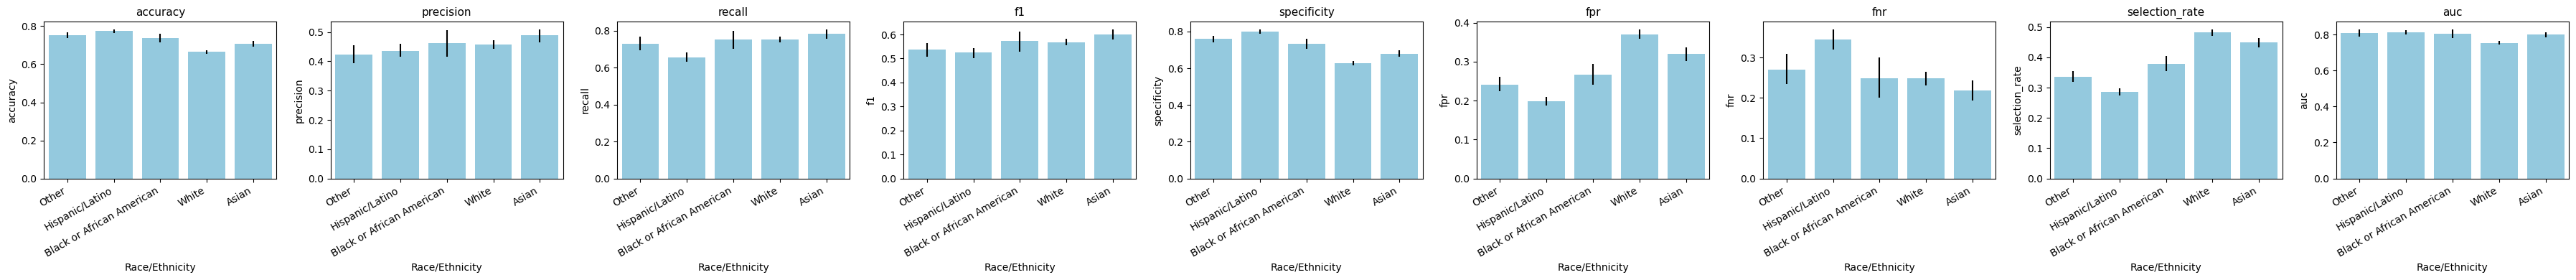

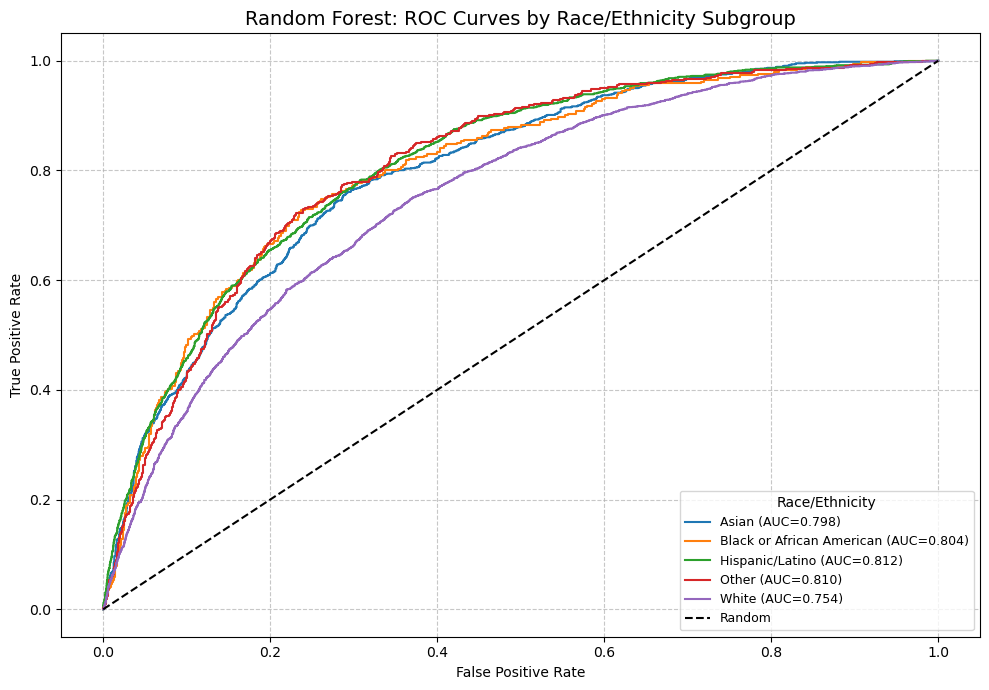

In [25]:
ci_df_race_ethnicity['Error Lower'] = ci_df_race_ethnicity['Mean'] - ci_df_race_ethnicity['CI_lower']
ci_df_race_ethnicity['Error Upper'] = ci_df_race_ethnicity['CI_upper'] - ci_df_race_ethnicity['Mean']

metrics = ci_df_race_ethnicity['Metric'].unique()
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    subset = ci_df_race_ethnicity[ci_df_race_ethnicity['Metric'] == metric]

    sns.barplot(
        data=subset,
        x='Group',
        y='Mean',
        yerr=[subset['Error Lower'], subset['Error Upper']],
        capsize=0.2,
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'{metric}', fontsize=11)
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

race_ethnicity_groups = fair_df_race_ethnicity['race_ethnicity'].unique()

plt.figure(figsize=(10, 7))

for group in sorted(race_ethnicity_groups):
    group_df = fair_df_race_ethnicity[fair_df_race_ethnicity['race_ethnicity'] == group]

    fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
    auc = roc_auc_score(group_df['y_true'], group_df['y_score'])

    plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Random Forest: ROC Curves by Race/Ethnicity Subgroup', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(title='Race/Ethnicity', loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 150]
age_labels = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']

age_grouped = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=True)
valid_mask = age_grouped.notna()

y_test_age = y_test[valid_mask]
y_pred_age = y_pred[valid_mask]
y_score_age = probs[:, 1][valid_mask]
age_grouped_clean = age_grouped[valid_mask]

fair_df_age = pd.DataFrame({
    'y_true': y_test_age,
    'y_pred': y_pred_age,
    'y_score': y_score_age,
    'age_group': age_grouped_clean
})

ci_df_age = bootstrap_fairness_metric_ci(
    df=fair_df_age,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='age_group',
    B=1000,
    random_seed=42
)

print("\n=== Random Forest Per-Age Group Metrics(Mean + 95% CI) ===")
for group in age_labels:
    if group in ci_df_age['Group'].values:
        group_metrics = ci_df_age[ci_df_age['Group'] == group]
        print(f"\nAge Group {group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")



=== Random Forest Per-Age Group Metrics(Mean + 95% CI) ===

Age Group 18–24:
accuracy         Mean = 0.86369, CI = (0.84777, 0.87935)
precision        Mean = 0.40214, CI = (0.34263, 0.46360)
recall           Mean = 0.46796, CI = (0.39912, 0.53685)
f1               Mean = 0.43203, CI = (0.37449, 0.48590)
specificity      Mean = 0.91311, CI = (0.89939, 0.92669)
fpr              Mean = 0.08689, CI = (0.07331, 0.10061)
fnr              Mean = 0.53204, CI = (0.46315, 0.60088)
selection_rate   Mean = 0.12919, CI = (0.11397, 0.14503)
auc              Mean = 0.80607, CI = (0.77457, 0.83498)

Age Group 25–34:
accuracy         Mean = 0.85539, CI = (0.84406, 0.86692)
precision        Mean = 0.41934, CI = (0.38028, 0.46098)
recall           Mean = 0.52331, CI = (0.47628, 0.56991)
f1               Mean = 0.46537, CI = (0.42958, 0.50691)
specificity      Mean = 0.90083, CI = (0.89061, 0.91055)
fpr              Mean = 0.09917, CI = (0.08945, 0.10939)
fnr              Mean = 0.47669, CI = (0.43009, 0

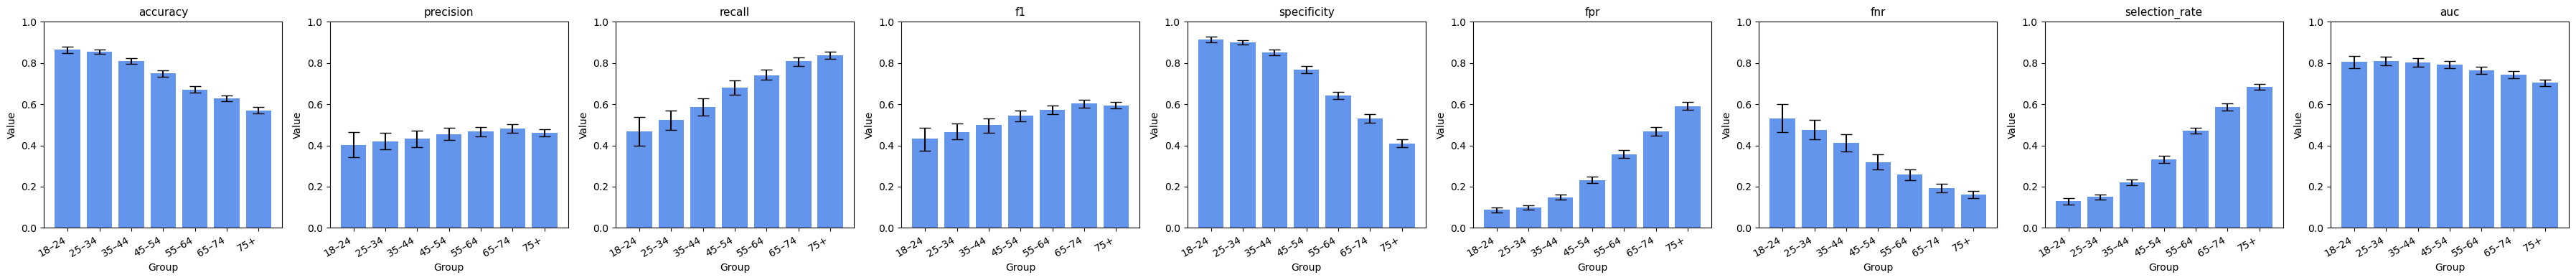

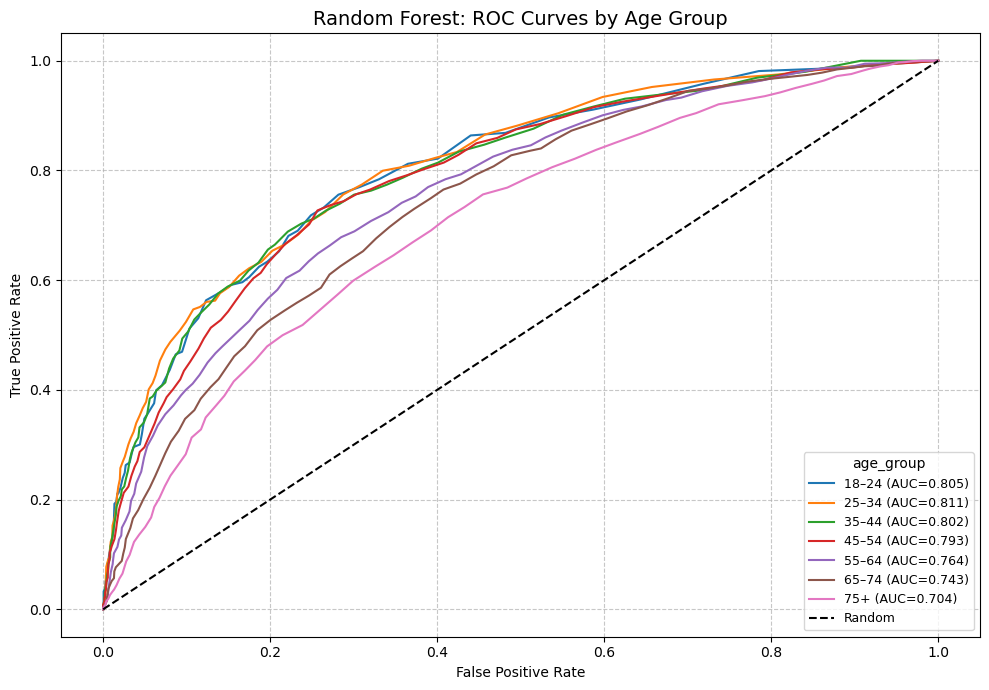

In [27]:
ci_df_age['Error Lower'] = ci_df_age['Mean'] - ci_df_age['CI_lower']
ci_df_age['Error Upper'] = ci_df_age['CI_upper'] - ci_df_age['Mean']

age_labels_ordered = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
ci_df_age['Group'] = pd.Categorical(ci_df_age['Group'], categories=age_labels_ordered, ordered=True)

plot_grouped_metrics_ci(ci_df_age, group_col='Group', cmap='cornflowerblue')
plot_group_roc_curves(fair_df_age, group_col='age_group', order=age_labels_ordered, title='Random Forest: ROC Curves by Age Group')

# Score News

score_NEWS
AUC: 0.6410573462943905
AUPRC: 0.36006668113410817
Sensitivity: 0.6684354673057172
Specificity: 0.5389836212699125
Score thresold: 1.0
2.5 97.5


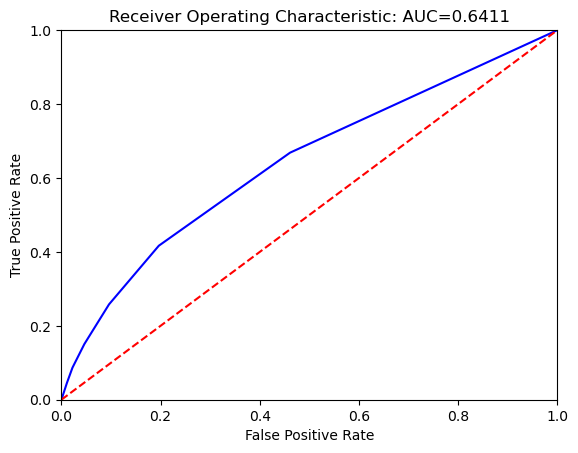

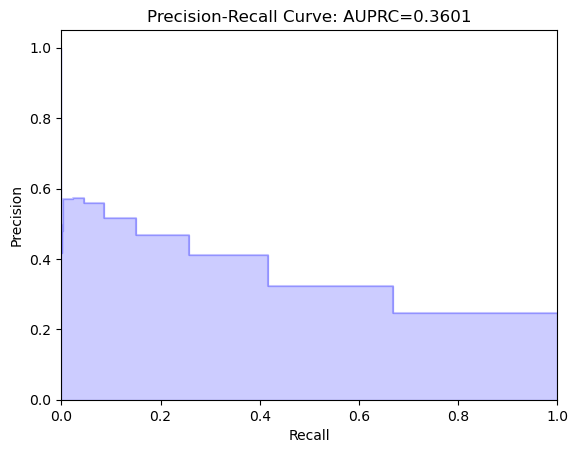

In [28]:
def get_score_performance_test(s, random_seed=0):
    print(s)
    score = np.array(df_test[s])
    result = PlotROCCurve(score, y_test, ci=confidence_interval, random_seed=random_seed)
    runtime = 0
    results = [s]
    results.extend(result)
    results.append(runtime)
    
    result_list.append(results)  

get_score_performance_test("score_NEWS", random_seed=random_seed)

In [29]:
NEWS_score = df_test["score_NEWS"]
y_pred_news_test = (NEWS_score >= 1.0).astype(int)

In [30]:
gender_map = {'F': 0, 'M': 1}
fair_df, gender_grouped, valid_mask_gender = prepare_group_fair_df('gender', mapping=gender_map)

ci_df_gender = bootstrap_fairness_metric_ci(
    df=fair_df,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='gender',
    B=1000,
    random_seed=42
)

print_bootstrap_group_metrics(
    ci_df_gender,
    group_label_to_id={'Female': 0, 'Male': 1},
    heading="=== Score NEWS Per-Gender Metrics (Mean + 95% CI) ==="
)


=== Score NEWS Per-Gender Metrics (Mean + 95% CI) ===

Female:
accuracy         Mean = 0.74255, CI = (0.73504, 0.75017)
precision        Mean = 0.44767, CI = (0.43325, 0.46285)
recall           Mean = 0.71068, CI = (0.69341, 0.72769)
f1               Mean = 0.54928, CI = (0.53527, 0.56266)
specificity      Mean = 0.75158, CI = (0.74314, 0.76012)
fpr              Mean = 0.24842, CI = (0.23988, 0.25686)
fnr              Mean = 0.28932, CI = (0.27231, 0.30659)
selection_rate   Mean = 0.35047, CI = (0.34187, 0.35865)
auc              Mean = 0.80248, CI = (0.79377, 0.81105)

Male:
accuracy         Mean = 0.69584, CI = (0.68723, 0.70400)
precision        Mean = 0.47005, CI = (0.45619, 0.48401)
recall           Mean = 0.75514, CI = (0.73976, 0.77034)
f1               Mean = 0.57939, CI = (0.56626, 0.59260)
specificity      Mean = 0.67307, CI = (0.66231, 0.68276)
fpr              Mean = 0.32693, CI = (0.31724, 0.33769)
fnr              Mean = 0.24486, CI = (0.22966, 0.26024)
selection_rate   

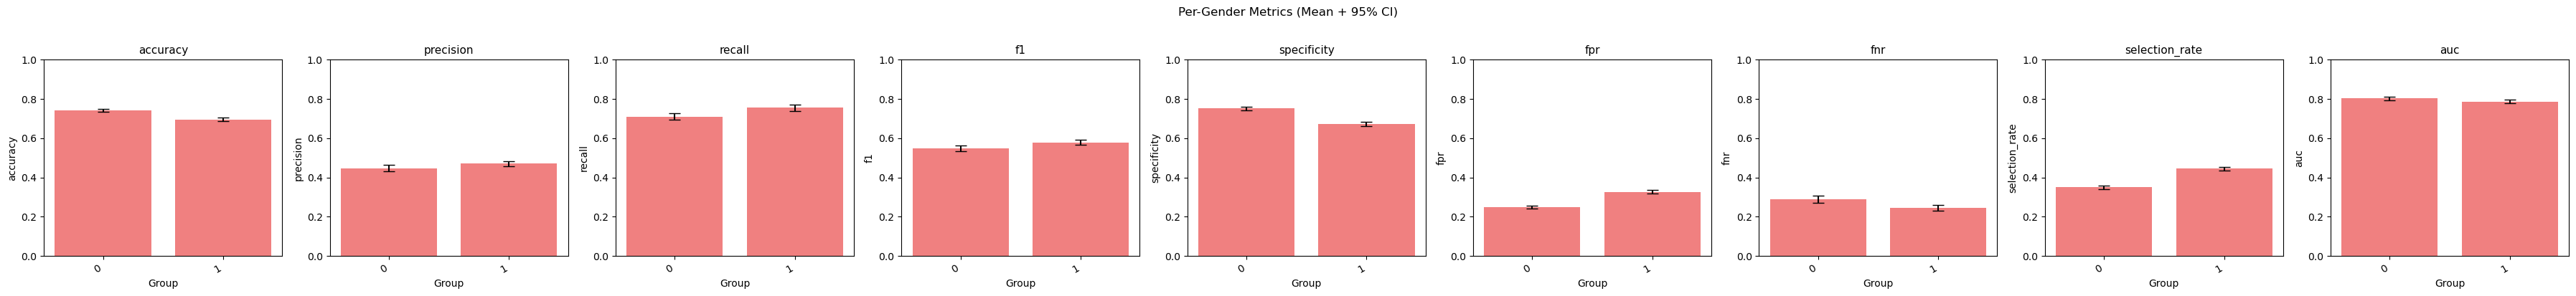

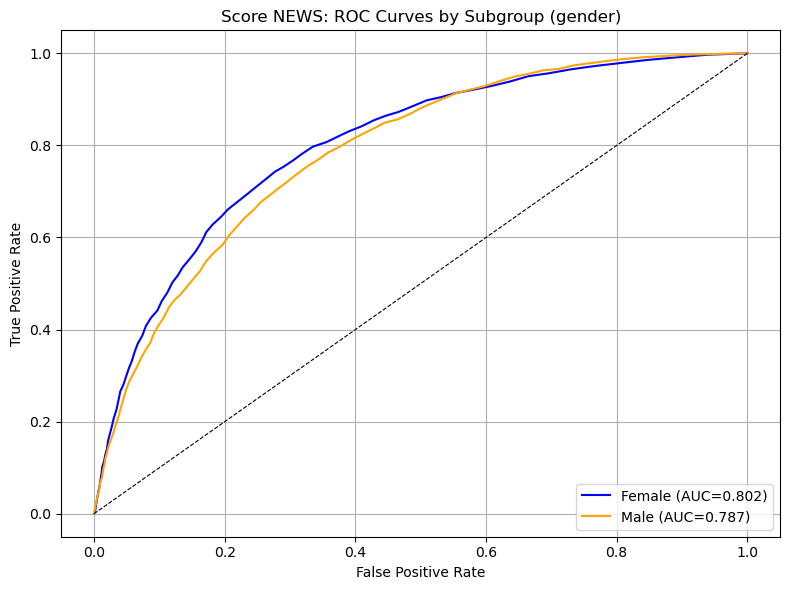

In [31]:
ci_df_gender = add_error_columns(ci_df_gender)

plot_group_ci(
    ci_df_gender,
    group_col='Group',
    mean_col='Mean',
    err_low='Error Lower',
    err_up='Error Upper',
    cmap='lightcoral',
    title='Per-Gender Metrics (Mean + 95% CI)'
)

label_map = {0: 'Female', 1: 'Male'}
plot_subgroup_roc(
    fair_df,
    group_col='gender',
    label_map=label_map,
    colors={0: 'blue', 1: 'orange'},
    title='Score NEWS: ROC Curves by Subgroup (gender)'
)

In [32]:
race_ethnicity_grouped = [map_race_ethnicity(r, e) for r, e in zip(race_clean, ethnicity_clean)]

fair_df_race_ethnicity = pd.DataFrame({
    'y_true': y_test_race_ethnicity,
    'y_pred': y_pred_race_ethnicity,
    'y_score': y_score_race_ethnicity,
    'race_ethnicity': race_ethnicity_grouped
})

ci_df_race_ethnicity = bootstrap_fairness_metric_ci(
    df=fair_df_race_ethnicity,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='race_ethnicity',
    B=1000,
    random_seed=42
)

print("\n=== Score NEWS Per-Race/Ethnicity Metrics (Mean + 95% CI) ===")
for group in ['Asian', 'Black or African American', 'Hispanic/Latino', 'Other', 'White']:
    if group in ci_df_race_ethnicity['Group'].values:
        group_metrics = ci_df_race_ethnicity[ci_df_race_ethnicity['Group'] == group]
        print(f"\n{group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


=== Score NEWS Per-Race/Ethnicity Metrics (Mean + 95% CI) ===

Asian:
accuracy         Mean = 0.70898, CI = (0.69367, 0.72270)
precision        Mean = 0.48852, CI = (0.46549, 0.50969)
recall           Mean = 0.78225, CI = (0.75660, 0.80694)
f1               Mean = 0.60136, CI = (0.58001, 0.62189)
specificity      Mean = 0.68039, CI = (0.66350, 0.69821)
fpr              Mean = 0.31961, CI = (0.30179, 0.33650)
fnr              Mean = 0.21775, CI = (0.19306, 0.24340)
selection_rate   Mean = 0.44947, CI = (0.43419, 0.46462)
auc              Mean = 0.79839, CI = (0.78308, 0.81263)

Black or African American:
accuracy         Mean = 0.73775, CI = (0.71418, 0.76001)
precision        Mean = 0.46218, CI = (0.41468, 0.50563)
recall           Mean = 0.75083, CI = (0.70026, 0.80000)
f1               Mean = 0.57184, CI = (0.52721, 0.61284)
specificity      Mean = 0.73380, CI = (0.70609, 0.75911)
fpr              Mean = 0.26620, CI = (0.24089, 0.29391)
fnr              Mean = 0.24917, CI = (0.20000

/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/2766506613.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/2766506613.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/2766506613.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/gt/9x17m7412yd64tl8r0gwfpbh0000gn/T/ipykernel_30905/2766506613.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

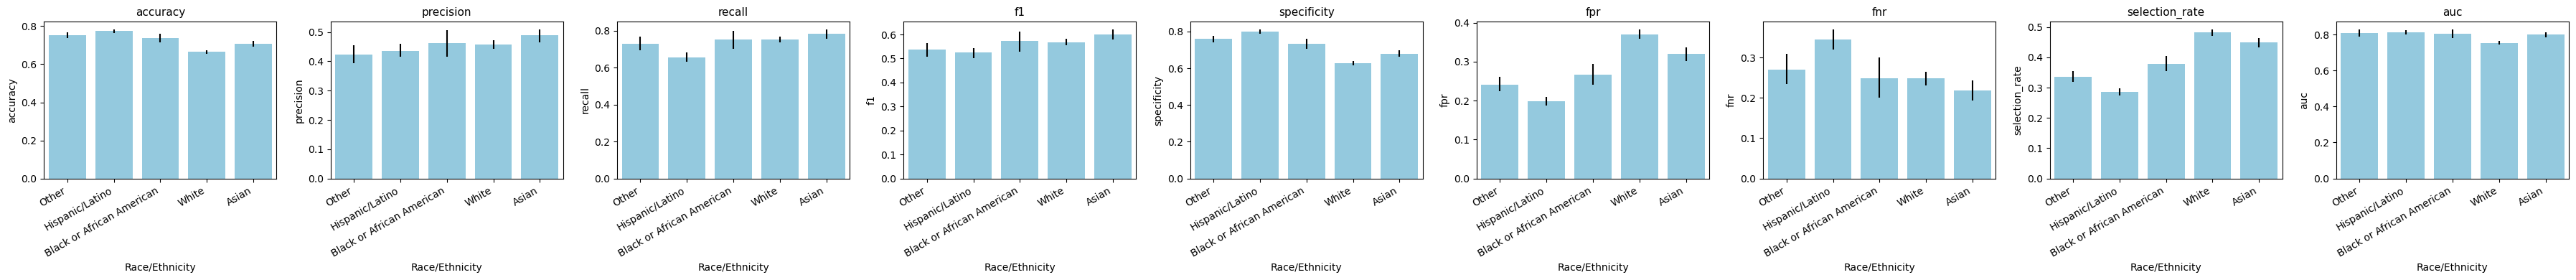

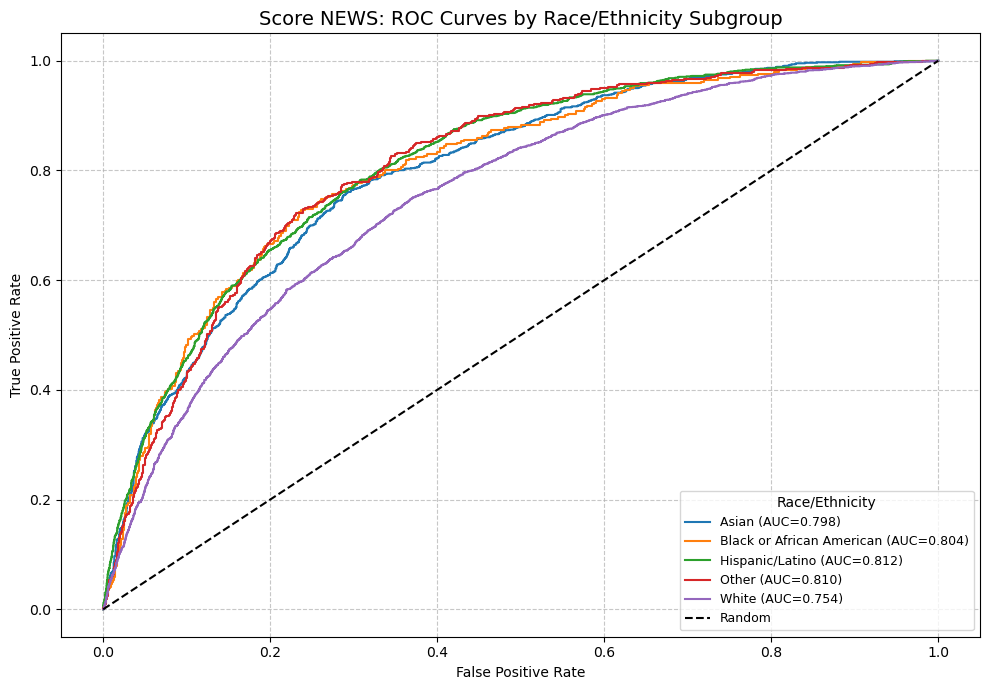

In [33]:
ci_df_race_ethnicity['Error Lower'] = ci_df_race_ethnicity['Mean'] - ci_df_race_ethnicity['CI_lower']
ci_df_race_ethnicity['Error Upper'] = ci_df_race_ethnicity['CI_upper'] - ci_df_race_ethnicity['Mean']

metrics = ci_df_race_ethnicity['Metric'].unique()
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    subset = ci_df_race_ethnicity[ci_df_race_ethnicity['Metric'] == metric]

    sns.barplot(
        data=subset,
        x='Group',
        y='Mean',
        yerr=[subset['Error Lower'], subset['Error Upper']],
        capsize=0.2,
        ax=ax,
        color='skyblue'
    )
    ax.set_title(f'{metric}', fontsize=11)
    ax.set_xlabel('Race/Ethnicity')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

race_ethnicity_groups = fair_df_race_ethnicity['race_ethnicity'].unique()

plt.figure(figsize=(10, 7))

for group in sorted(race_ethnicity_groups):
    group_df = fair_df_race_ethnicity[fair_df_race_ethnicity['race_ethnicity'] == group]

    fpr, tpr, _ = roc_curve(group_df['y_true'], group_df['y_score'])
    auc = roc_auc_score(group_df['y_true'], group_df['y_score'])

    plt.plot(fpr, tpr, label=f'{group} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Score NEWS: ROC Curves by Race/Ethnicity Subgroup', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(title='Race/Ethnicity', loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [34]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 150]
age_labels = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']

age_grouped = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=True)
valid_mask = age_grouped.notna()

y_test_age = y_test[valid_mask]
y_pred_age = y_pred[valid_mask]
y_score_age = probs[:, 1][valid_mask]
age_grouped_clean = age_grouped[valid_mask]

fair_df_age = pd.DataFrame({
    'y_true': y_test_age,
    'y_pred': y_pred_age,
    'y_score': y_score_age,
    'age_group': age_grouped_clean
})

ci_df_age = bootstrap_fairness_metric_ci(
    df=fair_df_age,
    y_true_col='y_true',
    y_pred_col='y_pred',
    y_score_col='y_score',
    group_col='age_group',
    B=1000,
    random_seed=42
)

print("\n=== Score NEWS Per-Age Group Metrics(Mean + 95% CI) ===")
for group in age_labels:
    if group in ci_df_age['Group'].values:
        group_metrics = ci_df_age[ci_df_age['Group'] == group]
        print(f"\nAge Group {group}:")
        for _, row in group_metrics.iterrows():
            metric = row['Metric']
            mean = row['Mean']
            ci_low = row['CI_lower']
            ci_high = row['CI_upper']
            print(f"{metric:<16} Mean = {mean:.5f}, CI = ({ci_low:.5f}, {ci_high:.5f})")


=== Score NEWS Per-Age Group Metrics(Mean + 95% CI) ===

Age Group 18–24:
accuracy         Mean = 0.86369, CI = (0.84777, 0.87935)
precision        Mean = 0.40214, CI = (0.34263, 0.46360)
recall           Mean = 0.46796, CI = (0.39912, 0.53685)
f1               Mean = 0.43203, CI = (0.37449, 0.48590)
specificity      Mean = 0.91311, CI = (0.89939, 0.92669)
fpr              Mean = 0.08689, CI = (0.07331, 0.10061)
fnr              Mean = 0.53204, CI = (0.46315, 0.60088)
selection_rate   Mean = 0.12919, CI = (0.11397, 0.14503)
auc              Mean = 0.80607, CI = (0.77457, 0.83498)

Age Group 25–34:
accuracy         Mean = 0.85539, CI = (0.84406, 0.86692)
precision        Mean = 0.41934, CI = (0.38028, 0.46098)
recall           Mean = 0.52331, CI = (0.47628, 0.56991)
f1               Mean = 0.46537, CI = (0.42958, 0.50691)
specificity      Mean = 0.90083, CI = (0.89061, 0.91055)
fpr              Mean = 0.09917, CI = (0.08945, 0.10939)
fnr              Mean = 0.47669, CI = (0.43009, 0.52

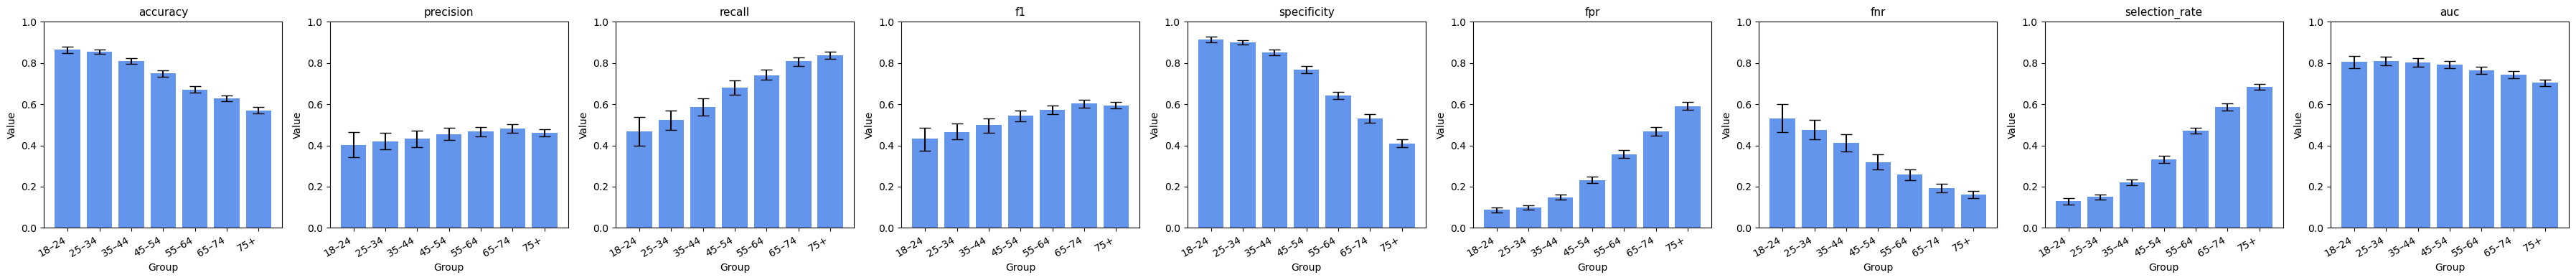

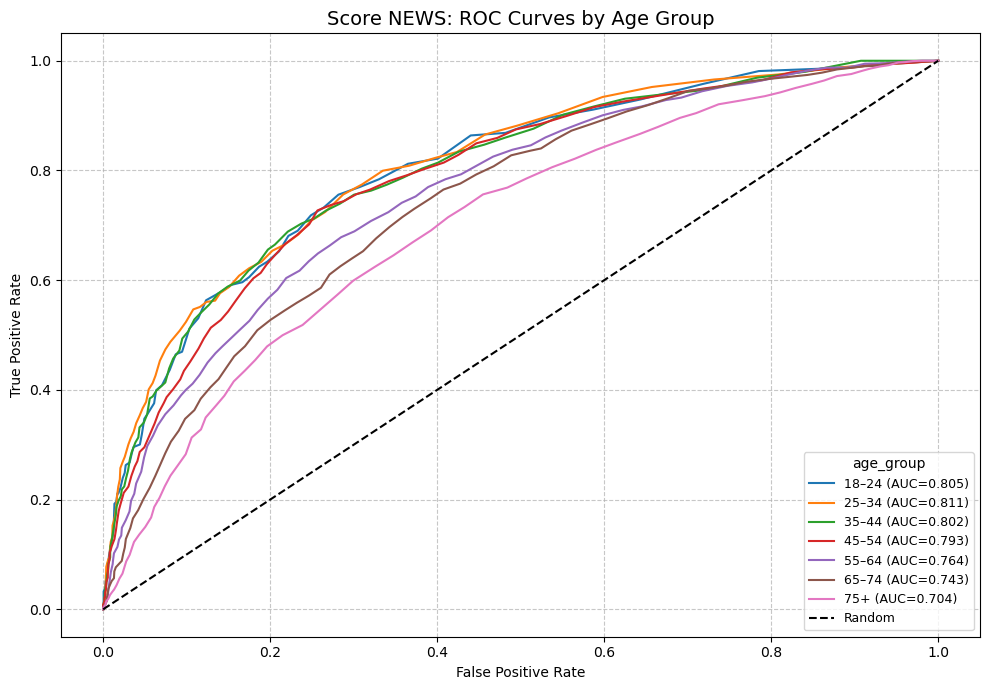

In [35]:
ci_df_age['Error Lower'] = ci_df_age['Mean'] - ci_df_age['CI_lower']
ci_df_age['Error Upper'] = ci_df_age['CI_upper'] - ci_df_age['Mean']

age_labels_ordered = ['0–17', '18–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
ci_df_age['Group'] = pd.Categorical(ci_df_age['Group'], categories=age_labels_ordered, ordered=True)

plot_grouped_metrics_ci(ci_df_age, group_col='Group', cmap='cornflowerblue')
plot_group_roc_curves(fair_df_age, group_col='age_group', order=age_labels_ordered, title='Score NEWS: ROC Curves by Age Group')